<a href="https://colab.research.google.com/github/hobbsandbobs-dotcom/Analytics-Coursework/blob/main/2_Python_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Importing library and loading NorthStar datasets

In [1]:
import pandas as pd

#Uploading cleaned datasets into Colab
from google.colab import files
file_uploaded = files.upload()

Saving vehicles_clean.csv to vehicles_clean.csv
Saving orders_clean.csv to orders_clean.csv
Saving incidents_clean.csv to incidents_clean.csv
Saving hubs_clean.csv to hubs_clean.csv
Saving drivers_clean.csv to drivers_clean.csv
Saving deliveries_clean.csv to deliveries_clean.csv
Saving customers_clean.csv to customers_clean.csv
Saving complaints_clean.csv to complaints_clean.csv
Saving app_events_clean.csv to app_events_clean.csv


In [2]:
#Loading the cleaned datasets
orders_df = pd.read_csv("orders_clean.csv")
deliveries_df = pd.read_csv("deliveries_clean.csv")
drivers_df = pd.read_csv("drivers_clean.csv")
vehicles_df = pd.read_csv("vehicles_clean.csv")
hubs_df = pd.read_csv("hubs_clean.csv")
incidents_df = pd.read_csv("incidents_clean.csv")
complaints_df = pd.read_csv("complaints_clean.csv")
customers_df = pd.read_csv("customers_clean.csv")
app_events_df = pd.read_csv("app_events_clean.csv")

In [3]:
#Importing the libraries for visualisation and analytics

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# 2. Functions and standardising names

In [4]:
columns_renamed = {
    'customer_id': 'Customer ID',
    'order_id': 'Order ID',
    'delivery_id': 'Delivery ID',
    'driver_id': 'Driver ID',
    'vehicle_id': 'Vehicle ID',
    'hub_id': 'Hub ID',
    'incident_id': 'Incident ID',
    'complaint_id': 'Complaint ID',
    'event_id': 'Event ID',
    'session_id': 'Session ID',

    'age': 'Age',
    'home_zone': 'Home Zone',
    'customer_type': 'Customer Type',
    'signup_date': 'Signup Date',
    'loyalty_score': 'Loyalty Score',
    'app_engagement_score': 'App Engagement Score',
    'preferred_channel': 'Preferred Channel',
    'account_status': 'Account Status',

    'base_zone': 'Base Zone',
    'employment_type': 'Employment Type',
    'years_experience': 'Years Experience',
    'training_score': 'Training Score',
    'driver_rating': 'Driver Rating',
    'shift_preference': 'Shift Preference',
    'active_flag': 'Active Flag',

    'vehicle_type': 'Vehicle Type',
    'assigned_zone': 'Assigned Zone',
    'commission_date': 'Commission Date',
    'battery_health_pct': 'Battery Health (%)',
    'odometer_km': 'Odometer (km)',
    'maintenance_status': 'Maintenance Status',
    'telematics_version': 'Telematics Version',

    'service_type': 'Service Type',
    'order_created_at': 'Order Created At',
    'promised_window_hours': 'Promised Window Hours',
    'pickup_zone': 'Pickup Zone',
    'dropoff_zone': 'Drop-off Zone',
    'priority_level': 'Priority Level',
    'order_value': 'Order Value',
    'booking_channel': 'Booking Channel',
    'special_handling_flag': 'Special Handling Flag',


    'dispatch_time': 'Dispatch Time',
    'delivery_completed_at': 'Delivery Completed At',
    'delivery_status': 'Delivery Status',
    'route_distance_km': 'Route Distance (km)',
    'manual_route_override_count': 'Manual Route Override Count',
    'proof_of_completion_missing': 'Proof of Completion Missing',
    'customer_rating_post_delivery': 'Customer Rating Post-Delivery',
    'fuel_or_charge_cost': 'Fuel / Charge Cost',

    'event_timestamp': 'Event Timestamp',
    'event_type': 'Event Type',
    'device_type': 'Device Type',
    'zone_context': 'Zone Context',
    'api_latency_ms': 'API Latency (ms)',
    'success_flag': 'Success Flag',

    'complaint_type': 'Complaint Type',
    'channel': 'Channel',
    'created_at': 'Created At',
    'status': 'Status',
    'resolution_days': 'Resolution Days',
    'compensation_amount': 'Compensation Amount',

    'hub_name': 'Hub Name',
    'zone': 'Zone',
    'hub_type': 'Hub Type',
    'capacity_score': 'Capacity Score',

    'file_name': 'File Name',
    'record_count': 'Record Count',
    'description': 'Description',

    'incident_type': 'Incident Type',
    'reported_at': 'Reported At',
    'severity': 'Severity',
    'resolution_status': 'Resolution Status',
    'resolved_hours': 'Resolved Hours',
}

In [5]:
def cleaning_zones(label):
    return columns_renamed.get(
        label,
        str(label).replace("_", " ").title().replace(" Id", " ID")
    )

In [7]:
def table_formatting(datasets, header, cmap="Purples"):

  datasets = datasets.copy()

  datasets.index = [cleaning_zones(label) for label in datasets.index]
  datasets.columns = [cleaning_zones(label) for label in datasets.columns]

  return datasets.style \
        .set_caption(header) \
        .format(precision=2) \
        .background_gradient(cmap=cmap) \
        .set_properties(**{
            'text-align': 'center',
            'font-size': '11pt'
        }) \
        .set_table_styles([
            {'selector': 'caption',
             'props': [
                 ('font-size', '11pt'),
                 ('font-weight', 'bold'),
                 ('text-align', 'center')
             ]},
            {'selector': 'th.col_heading',
             'props': [
                 ('font-size', '9pt'),
                 ('font-weight', 'normal')
             ]}
        ])

In [6]:
def clean_zone(col):
    return (
        col.str.strip()
           .str.title()
           .replace({'Ctr': 'Central'})
    )

#3. Data Analysis

3.1. Orders and Delivieries Data Overview

In [9]:
orders_and_deliveries_df = orders_df.merge(
    deliveries_df,
    on="order_id",
    how="left",
    indicator=True
)

3.1.1 Incomplete delivery records

In [57]:
#Orders and delivery number of records overview
deliveries_orders_record_overview = (
    orders_and_deliveries_df["_merge"]
    .value_counts()
    .to_frame(name="N. Records")
)

deliveries_orders_record_overview = deliveries_orders_record_overview.drop(
    index="right_only",
    errors="ignore"
)

deliveries_orders_record_overview["Overall %"] = (
    deliveries_orders_record_overview["N. Records"] /
    deliveries_orders_record_overview["N. Records"].sum() * 100
).round(2)

deliveries_orders_record_overview = deliveries_orders_record_overview.rename(index={
    "both": "Both Order and Delivery Record",
    "left_only": "Order Record but no Delivery"
})

deliveries_orders_record_overview["Visibility"] = np.where(
    deliveries_orders_record_overview.index == "Both Order and Delivery Record",
    "Fully traceable",
    "Records missing"
)

deliveries_orders_record_overview = deliveries_orders_record_overview.reindex([
    "Both Order and Delivery Record",
    "Order Record but no Delivery"
])

deliveries_orders_record_overview = deliveries_orders_record_overview[
    [
        "Visibility",
        "N. Records",
        "Overall %"
    ]
]

table_formatting(
    deliveries_orders_record_overview,
    "Orders and Deliveries: Available Records"
)

,Visibility,N. Records,Overall %
Both Order And Delivery Record,Fully traceable,950,76.00
Order Record But No Delivery,Records missing,300,24.00


3.1.2 Zone pattern analysis

In [58]:
orders_and_deliveries_df["delivery_record_found"] = (
    orders_and_deliveries_df["_merge"] == "both"
)

orders_and_deliveries_df["delivery_record_missing"] = (
    orders_and_deliveries_df["_merge"] == "left_only"
)

orders_and_deliveries_df["delivery_complete"] = (
    orders_and_deliveries_df["delivery_complete_flag"] == True
)

orders_and_deliveries_df["delivery_on_time"] = (
    orders_and_deliveries_df["delivery_status"] == "OnTime"
)

orders_and_deliveries_df["delivery_was_delayed"] = (
    orders_and_deliveries_df["delivery_status"] == "Delayed"
)

orders_and_deliveries_df["delivery_failed"] = (
    orders_and_deliveries_df["delivery_status"] == "Failed"
)
#Flags created

In [67]:
#grouped dataframe to show the service-type failure combinations

service_zone_failures = (
    orders_and_deliveries_df
    .groupby(["pickup_zone", "service_type"])
    .agg(
        orders_total=("order_id", "count"),
        failed_deliveries=("delivery_failed", "sum")
    )
)

#Calculated the total number of delivery failures within the service-zone

service_zone_failures["percent_failed"] = (
    service_zone_failures["failed_deliveries"] /
    service_zone_failures["orders_total"] * 100
).round(2)

service_zone_failures = service_zone_failures[
    service_zone_failures["orders_total"] >= 16
]

#Ensured that the highest risk zones were listed first, and the top 20 through .head()
service_zone_failures = (
    service_zone_failures
    .sort_values("percent_failed", ascending=False)
    .head(20)
    .reset_index()
)

service_zone_failures["Service-Zone"] = (
    service_zone_failures["pickup_zone"] +
    " | " +
    service_zone_failures["service_type"]
)
#concatenating the zone and service type for output

service_zone_failures = service_zone_failures.rename(columns={
    "pickup_zone": "In Zone",
    "service_type": "Services",
    "orders_total": "Order Total",
    "percent_failed": "Failed %"
})

table_formatting(
    service_zone_failures[
        ["In Zone", "Services", "Order Total", "Failed %"]
    ],
    "Service - In Zone (Pickup) Failed Deliveries"
)
#formated table function


,In Zone,Services,Order Total,Failed %
0,North,Medical,19,31.58
1,Central,Business,30,20.00
2,North,Business,25,20.00
3,Central,Retail,65,20.00
4,Riverside,Business,22,18.18
5,South,Business,23,17.39
6,Airport,Business,19,15.79
7,East,Passenger,55,14.55
8,Central,Medical,21,14.29
9,West,Passenger,42,14.29


In [63]:
service_zone_failures.head()

,In Zone,Services,Order Total,failed_deliveries,Failed %,Service-Zone
0,North,Medical,19,6,31.58,North | Medical
1,Central,Business,30,6,20.00,Central | Business
2,North,Business,25,5,20.00,North | Business
3,Central,Retail,65,13,20.00,Central | Retail
4,Riverside,Business,22,4,18.18,Riverside | Business


In [69]:
north_only = service_zone_failures[
    service_zone_failures["In Zone"].str.startswith("North")
]

In [70]:
north_only

,In Zone,Services,Order Total,failed_deliveries,Failed %,Service-Zone
0,North,Medical,19,6,31.58,North | Medical
2,North,Business,25,5,20.00,North | Business
11,North,Retail,40,5,12.50,North | Retail
13,North,Passenger,47,5,10.64,North | Passenger


In [74]:
service_zone_top_failures = service_zone_failures.set_index(["In Zone", "Services"])


In [75]:
service_zone_top_failures

,,Order Total,failed_deliveries,Failed %,Service-Zone
In Zone,Services,,,,
North,Medical,19,6,31.58,North | Medical
Central,Business,30,6,20.00,Central | Business
North,Business,25,5,20.00,North | Business
Central,Retail,65,13,20.00,Central | Retail
Riverside,Business,22,4,18.18,Riverside | Business
South,Business,23,4,17.39,South | Business
Airport,Business,19,3,15.79,Airport | Business
East,Passenger,55,8,14.55,East | Passenger
Central,Medical,21,3,14.29,Central | Medical


In [73]:
service_zone_top_failures.loc[("North", "Medical")]

,North
,Medical
Order Total,19
failed_deliveries,6
Failed %,31.58
Service-Zone,North | Medical


3.2. Drivers and deliveries

3.2.1 Delivery and ratings

In [17]:
deliveries_drivers_df = deliveries_df.merge(
    drivers_df,
    on="driver_id",
    how="left",
    indicator=True
)

table_formatting(
    deliveries_drivers_df["_merge"].value_counts().to_frame("Count"),
    "Drivers and Deliveries Record Alignment"
)

,Count
Both,950
Left Only,0
Right Only,0


In [85]:
#Creating a delivery rating table
delivery_rating_outcomes = (
    deliveries_drivers_df
    .groupby("delivery_status")
    .agg(
        delivery_count=("delivery_id", "count"),
        avg_customer_rating=("customer_rating_post_delivery", "mean"),
        med_customer_rating=("customer_rating_post_delivery", "median"),
        rating_std=("customer_rating_post_delivery", "std"),
    )
    .round(2)
)

table_formatting(
   delivery_rating_outcomes,
    "Delivery outcomes and Customer Rating"
)

,Delivery Count,Avg Customer Rating,Med Customer Rating,Rating Std
Delayed,202,3.11,3.20,0.94
Failed,132,3.05,3.03,0.88
Ontime,616,4.28,4.32,0.53


In [86]:
filtered = delivery_rating_outcomes.loc[delivery_rating_outcomes["delivery_count"] >= 25,
                                       ["delivery_count", "avg_customer_rating"]]

In [87]:
filtered

,delivery_count,avg_customer_rating
delivery_status,,
Delayed,202,3.11
Failed,132,3.05
OnTime,616,4.28


In [88]:
filtered_graph = filtered.reset_index()

/tmp/ipykernel_4334/2662181588.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


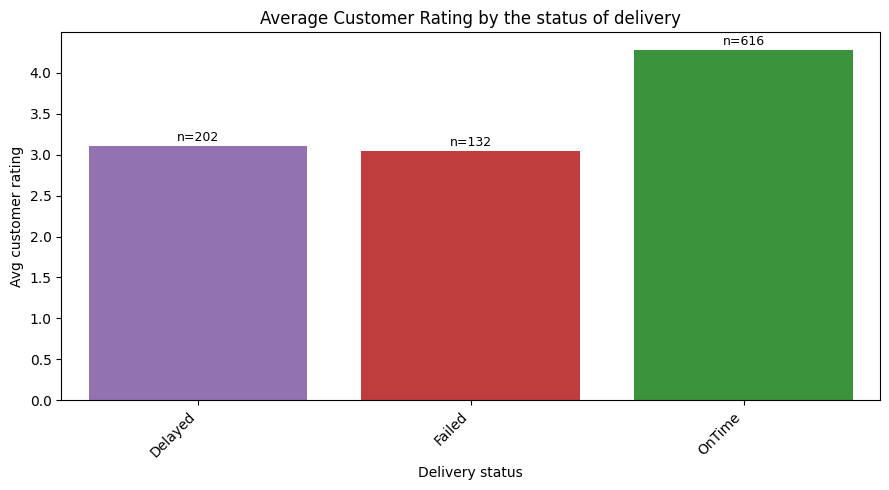

In [102]:
rating_colours = {
 "OnTime": "#2ca02c",
    "Failed": "#d62728",
    "Delayed": "#9467bd"
}

plt.figure(figsize=(9,5))
ax = sns.barplot(
    data=filtered_graph,
    x="delivery_status",
    y="avg_customer_rating",
    errorbar=None,
    palette=rating_colours
)


for i, row in filtered.reset_index(drop=True).iterrows():
    ax.text(
        i,
        row["avg_customer_rating"] + 0.02,
        f'n={int(row["delivery_count"])}',
        ha="center", va="bottom", fontsize=9
    )

plt.xticks(rotation=45, ha="right")
plt.title("Average Customer Rating by the status of delivery")
plt.xlabel("Delivery status")
plt.ylabel("Avg customer rating")
plt.tight_layout()
plt.show()

3.2.2 Battery health within the vehicles

# BATTERY HEALTH

In [23]:
deliveries_vehicles_df = deliveries_df.merge(
    vehicles_df,
    on="vehicle_id",
    how="left",
    indicator=True
)

table_formatting(
    deliveries_vehicles_df["_merge"].value_counts().to_frame("Count"),
    "Delivery and Vehicles Record Overview"
)

,Count
Both,950
Left Only,0
Right Only,0


In [ ]:
#BETTERY

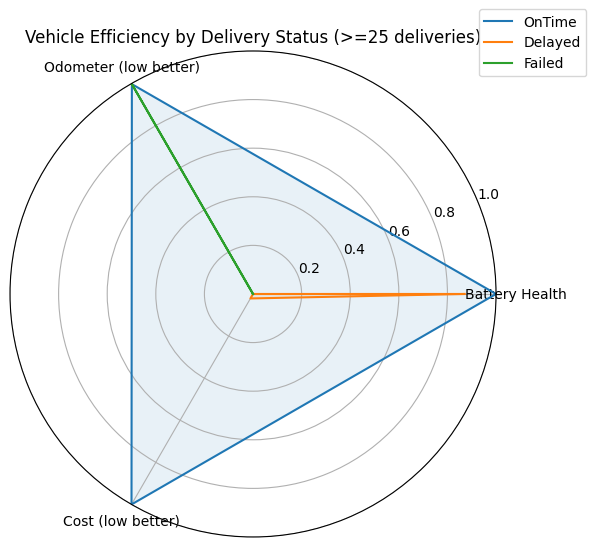

In [24]:


vehicle_efficiency = (
    deliveries_vehicles_df
    .groupby("delivery_status")
    .agg(
        avg_battery_health=("battery_health_pct", "mean"),
        avg_odometer_km=("odometer_km", "mean"),
        avg_fuel_cost=("fuel_or_charge_cost", "mean"),
        n=("delivery_id", "count")
    )
    .round(2)
)

vehicle_efficiency = vehicle_efficiency[vehicle_efficiency["n"] >= 25]

#Metrics for the radar
radar = vehicle_efficiency[
    ["avg_battery_health", "avg_odometer_km", "avg_fuel_cost"]
]

#Creating radar
radar_scaled = (radar - radar.min()) / (radar.max() - radar.min())

#Making it so the higher is the better output for the fuel and odometer
radar_scaled["avg_fuel_cost"] = 1 - radar_scaled["avg_fuel_cost"]
radar_scaled["avg_odometer_km"] = 1 - radar_scaled["avg_odometer_km"]

radar_scaled = radar_scaled.sort_values("avg_battery_health", ascending=False)


#Creating the labels for the chart
labels = ["Battery Health", "Odometer (low better)", "Cost (low better)"]
angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False)
angles = np.concatenate([angles, [angles[0]]])

plt.figure(figsize=(6,6))
ax = plt.subplot(111, polar=True)

#For loop per status
for status in radar_scaled.index:
    values = radar_scaled.loc[status].values
    values = np.concatenate([values, [values[0]]])

    ax.plot(angles, values, label=status)
    ax.fill(angles, values, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
ax.set_title("Vehicle Efficiency by the type of delivery")
ax.set_ylim(0, 1)

plt.legend(loc="upper right", bbox_to_anchor=(1.2, 1.1))
plt.tight_layout()
plt.show()

vehicle and deliveries

In [25]:
deliveries_and_hubs_df = deliveries_df.merge(
    hubs_df,
    on="hub_id",
    how="left"
)

In [26]:
deliveries_and_hubs_df.head()

,delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,...,customer_rating_post_delivery,fuel_or_charge_cost,delivery_complete_flag,rating_recorded_flag,deliv_complete_at_flag,deliv_rating_recorded_flag,hub_name,zone,hub_type,capacity_score
0,DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59.904311,Failed,17.26,1,...,3.07,12.05,True,True,True,True,Central Core,Central,Control,88
1,DL00002,O00004,D138,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00.000000,OnTime,10.34,1,...,5.00,13.41,True,True,True,True,South Link,South,Dispatch,78
2,DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,2025-06-02 21:45:32.366770,OnTime,7.92,0,...,4.98,8.51,True,True,True,True,South Link,South,Dispatch,78
3,DL00004,O00313,D116,V055,H02,2024-03-08 23:31:00,2024-03-09 23:30:08.103702,Delayed,16.42,0,...,4.18,13.62,True,True,True,True,South Link,South,Dispatch,78
4,DL00005,O00844,D108,V034,H01,2025-09-21 11:43:00,2025-09-21 15:45:34.131056,OnTime,14.52,1,...,4.18,9.22,True,True,True,True,North Exchange,North,Dispatch,82


In [106]:

min_deliveries = 25

df = deliveries_and_hubs_df.copy()

#Creating vector flags
df["is_delayed"] = (df["delivery_status"] == "Delayed").astype(int)
df["is_failed"]  = (df["delivery_status"] == "Failed").astype(int)

performance_of_hubs = (
    df.groupby(["hub_name", "hub_type"], dropna=False)
      .agg(
          total_deliveries=("delivery_id", "count"),
          delayed_deliveries=("is_delayed", "sum"),
          failed_deliveries=("is_failed", "sum"),
          avg_manual_overrides=("manual_route_override_count", "mean"),
          avg_operational_costs=("fuel_or_charge_cost", "mean"),
          avg_capacity_score=("capacity_score", "mean"),
      )
)

#Filtering the hubs
performance_of_hubs = performance_of_hubs.loc[
    performance_of_hubs["total_deliveries"] >= min_deliveries
].copy()

calc = performance_of_hubs["total_deliveries"]

performance_of_hubs["failed_percent"] = np.where(
    calc > 0, performance_of_hubs["failed_deliveries"] / calc * 100, np.nan
).round(2)

performance_of_hubs["delayed_percent"] = np.where(
    calc > 0, performance_of_hubs["delayed_deliveries"] / calc * 100, np.nan
).round(2)

#Creating a proxy for the success of the hubs
performance_of_hubs["not_failed_or_delayed_percent"] = (
    100 - performance_of_hubs["failed_percent"] - performance_of_hubs["delayed_percent"]
).round(2)

#Having a rank for the worst performance per hub
performance_of_hubs["risk_rank"] = (
    performance_of_hubs[["failed_percent", "delayed_percent"]]
    .sum(axis=1)
    .rank(ascending=False, method="dense")
    .astype(int)
)

#Sorting by the percentage of failed, then delayed
performance_of_hubs = (
    performance_of_hubs
    .round(2)
    .sort_values(["failed_percent", "delayed_percent"], ascending=False)
)

table_formatting(
    performance_of_hubs.reset_index(),
    "Hubs and delivery outcomes"
)

,Hub Name,Hub Type,Total Deliveries,Delayed Deliveries,Failed Deliveries,Avg Manual Overrides,Avg Operational Costs,Avg Capacity Score,Failed Percent,Delayed Percent,Not Failed Or Delayed Percent,Risk Rank
0,Midtown Relay,Charging,128,22,26,1.11,11.71,63.00,20.31,17.19,62.50,3
1,Central Core,Control,115,25,23,0.95,13.69,88.00,20.00,21.74,58.26,1
2,Airport Hub,Dispatch,104,27,15,0.91,13.32,71.00,14.42,25.96,59.62,2
3,West Gate,Dispatch,127,28,16,0.87,13.17,69.00,12.60,22.05,65.35,4
4,North Exchange,Dispatch,136,26,17,1.03,12.76,82.00,12.50,19.12,68.38,7
5,Riverside Hub,Warehouse,115,25,14,1.05,12.92,66.00,12.17,21.74,66.09,6
6,South Link,Dispatch,106,26,10,0.92,12.57,78.00,9.43,24.53,66.04,5
7,East Dock,Warehouse,119,23,11,0.89,12.74,74.00,9.24,19.33,71.43,8


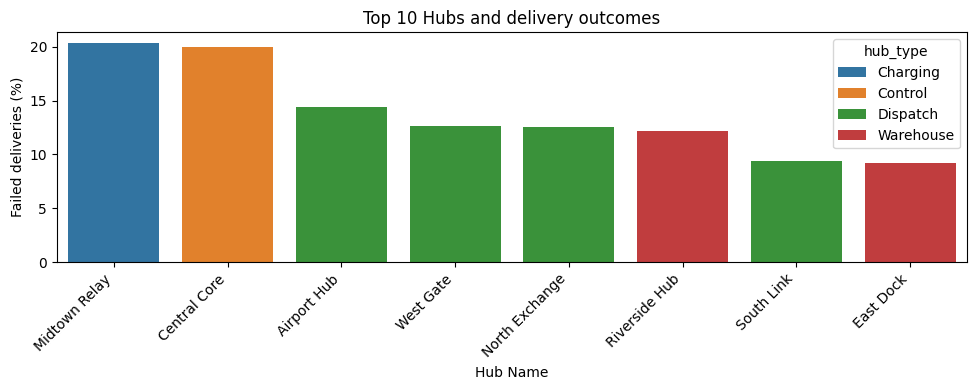

In [108]:

plot_df = performance_of_hubs.reset_index().head(20)

plt.figure(figsize=(10,4))
sns.barplot(data=plot_df, x="hub_name", y="failed_percent", hue="hub_type", errorbar=None)
plt.xticks(rotation=45, ha="right")
plt.title("Top 10 Hubs and delivery outcomes")
plt.ylabel("Failed deliveries (%)")
plt.xlabel("Hub Name")
plt.tight_layout()
plt.show()

In [110]:
top_three_hubs = (
    performance_of_hubs
    .reset_index()
    .sort_values("failed_percent", ascending=False)
    .head(3)
)

top_three_hub_names = top_three_hubs["hub_name"].tolist()
top_three_hub_names


['Midtown Relay', 'Central Core', 'Airport Hub']

In [118]:
deliv = (
    deliveries_df
    .merge(hubs_df[["hub_id", "hub_name"]], on="hub_id", how="left", validate="m:1")
    .merge(vehicles_df[["vehicle_id", "vehicle_type"]], on="vehicle_id", how="left", validate="m:1")
)

In [119]:
top_df = deliv[deliv["hub_name"].isin(top_three_hub_names)].copy()

vehicle_type_counts = (
    top_df
    .groupby(["hub_name", "vehicle_type"])
    .size()
    .reset_index(name="deliveries")
)

In [120]:
most_common_vehicle_type = (
    vehicle_type_counts
    .sort_values(["hub_name", "deliveries"], ascending=[True, False])
    .groupby("hub_name")
    .head(1)
    .reset_index(drop=True)
)

most_common_vehicle_type

,hub_name,vehicle_type,deliveries
0,Airport Hub,EV,32
1,Central Core,EV,46
2,Midtown Relay,EV,46


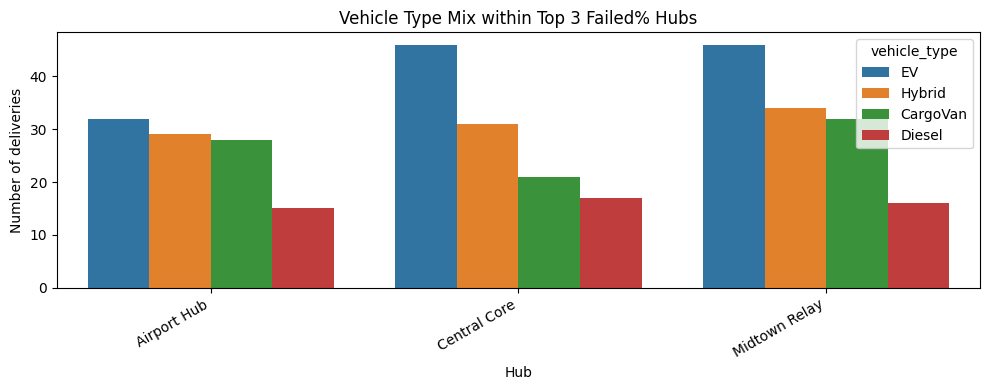

In [121]:
plt.figure(figsize=(10,4))
sns.barplot(
    data=vehicle_type_counts.sort_values(["hub_name", "deliveries"], ascending=[True, False]),
    x="hub_name",
    y="deliveries",
    hue="vehicle_type",
    errorbar=None
)
plt.xticks(rotation=30, ha="right")
plt.title("Vehicle Type Mix within Top 3 Failed% Hubs")
plt.xlabel("Hub")
plt.ylabel("Number of deliveries")
plt.tight_layout()
plt.show()

In [124]:
deliv["is_failed"] = (deliv["delivery_status"] == "Failed").astype(int)
deliv["is_ev"] = (deliv["vehicle_type"] == "EV").astype(int)


hub_analysis = (
    df.groupby("hub_name")
    .agg(
        total_deliveries=("delivery_id", "count"),
        failed_percent=("is_failed", "mean"),
        ev_share=("is_ev", "mean")
    )
)

hub_analysis["failed_percent"] = (hub_analysis["failed_percent"] * 100).round(2)
hub_analysis["ev_share"] = (hub_analysis["ev_share"] * 100).round(2)

hub_analysis = hub_analysis[hub_analysis["total_deliveries"] >= 25]

In [125]:
correlation = hub_analysis[["ev_share", "failed_percent"]].corr().iloc[0, 1]

print(correlation)

0.10783751728416563


xx

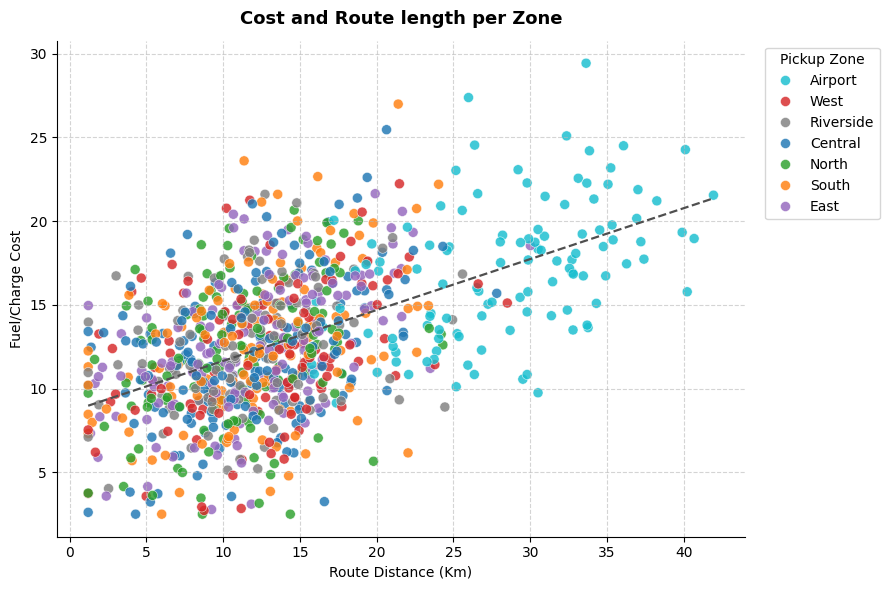

In [126]:
costing_distance_data = orders_and_deliveries_df.dropna(
    subset=["route_distance_km", "fuel_or_charge_cost", "pickup_zone"]
).copy()

zone_colours = {
    "Central": "#1F77B4",
    "West": "#D62728",
    "East": "#9467BD",
    "South": "#FF7F0E",
    "North": "#2CA02C",
    "Airport": "#17BECF",
    "Riverside": "#7F7F7F"
}

plt.figure(figsize=(9, 6))

#Creating the different colours by zone
sns.scatterplot(
    data=costing_distance_data,
    x="route_distance_km",
    y="fuel_or_charge_cost",
    hue="pickup_zone",
    palette=zone_colours,
    alpha=0.82,
    s=52,
    edgecolor="white",
    linewidth=0.4
)

#Creating the line trend
sns.regplot(
    data=costing_distance_data,
    x="route_distance_km",
    y="fuel_or_charge_cost",
    scatter=False,
    color="#4F4F4F",
    line_kws={"linestyle": "--", "linewidth": 1.6},
    ci=None
)

plt.title("Cost and Route length per Zone", fontsize=13, weight="bold", pad=12)
plt.xlabel("Route Distance (Km)", fontsize=10)
plt.ylabel("Fuel/Charge Cost", fontsize=10)
plt.grid(color="#B8B8B8", linestyle="--", alpha=0.6)

sns.despine()
plt.legend(title="Pickup Zone", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True)
plt.tight_layout()
plt.show()

In [37]:
def slope(x, y):
    m, b = np.polyfit(x, y, 1)
    return m

zone_stats = (
    costing_distance_data
    .groupby("pickup_zone")
    .apply(lambda g: pd.Series({
        "n": len(g),
        "corr_r": g["route_distance_km"].corr(g["fuel_or_charge_cost"]),
        "slope_cost_per_km": slope(g["route_distance_km"], g["fuel_or_charge_cost"])
    }))
    .reset_index()
)

zone_stats["corr_r"] = zone_stats["corr_r"].round(3)
zone_stats["slope_cost_per_km"] = zone_stats["slope_cost_per_km"].round(3)

zone_stats.sort_values("slope_cost_per_km", ascending=False)

/tmp/ipykernel_4334/2684543126.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


,pickup_zone,n,corr_r,slope_cost_per_km
2,East,156.0,0.515,0.389
5,South,139.0,0.437,0.368
1,Central,174.0,0.409,0.329
0,Airport,113.0,0.465,0.309
3,North,135.0,0.326,0.290
6,West,114.0,0.390,0.288
4,Riverside,119.0,0.293,0.216


# digital and system fragmentation

In [38]:
app_orders_df = app_events_df.merge(
    orders_df,
    on="order_id",
    how="left",
    indicator=True
)

In [39]:
df = app_orders_df.copy()
df["is_failed"] = (df["success_flag"] == 0).astype(int)

event_type_analysis = (
    df.groupby("event_type", dropna=False)
      .agg(
          total_events=("event_id", "count"),
          failed_events=("is_failed", "sum"),
          failure_rate=("is_failed", "mean"),
          avg_latency=("api_latency_ms", "mean"),
          p95_latency=("api_latency_ms", lambda s: s.quantile(0.95)),
          latency_missing_pct=("api_latency_ms", lambda s: s.isna().mean() * 100),
      )
)

event_type_analysis["failure_percent"] = (event_type_analysis["failure_rate"] * 100).round(2)
event_type_analysis["avg_latency"] = event_type_analysis["avg_latency"].round(2)
event_type_analysis["p95_latency"] = event_type_analysis["p95_latency"].round(2)
event_type_analysis["latency_missing_pct"] = event_type_analysis["latency_missing_pct"].round(2)

event_type_analysis = event_type_analysis.sort_values("failure_percent", ascending=False)

In [127]:
table_formatting(
    event_type_analysis.reset_index()[["event_type", "total_events", "failure_percent", "avg_latency", "p95_latency"]],
    "Platform Events and their details"
)

,Event Type,Total Events,Failure Percent,Avg Latency,P95 Latency
0,chat_escalated,38,50.00,478.13,1083.60
1,payment_retry,69,27.54,472.68,863.80
2,chat_opened,88,0.00,478.33,1079.15
3,cancel_attempt,28,0.00,417.14,789.35
4,delivery_instruction_update,75,0.00,496.29,924.90
5,eta_refresh,105,0.00,452.15,802.40
6,search_route,99,0.00,456.51,786.00
7,track_order,138,0.00,460.71,868.70


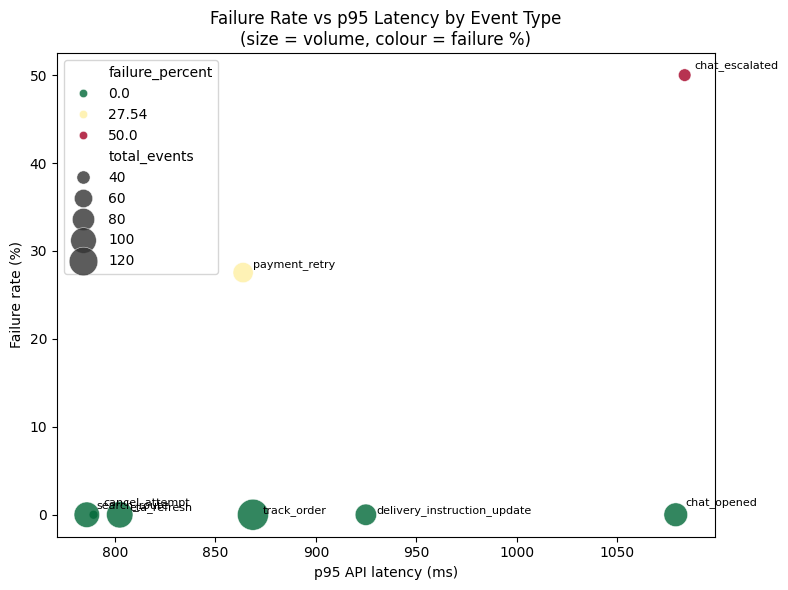

In [128]:

min_n = 20

plot_df = (
    event_type_analysis
    .reset_index()
    .query("total_events >= @min_n")
    .copy()
)

plt.figure(figsize=(8, 6))
ax = sns.scatterplot(
    data=plot_df,
    x="p95_latency",
    y="failure_percent",
    size="total_events",
    hue="failure_percent",
    palette="RdYlGn_r",
    sizes=(40, 500),
    alpha=0.80,
    edgecolor="white",
    linewidth=0.4
)

label_df = plot_df.nlargest(10, "total_events")
offsets = [0.2, 0.5, 0.8, 1.1]

for i, (_, r) in enumerate(label_df.iterrows()):
    ax.text(
        r["p95_latency"] + 5,
        r["failure_percent"] + offsets[i % len(offsets)],
        str(r["event_type"]),
        fontsize=8
    )

plt.title("Failure Rate vs p95 Latency by Event Type\n(size = volume, colour = failure %)")
plt.xlabel("p95 API latency (ms)")
plt.ylabel("Failure rate (%)")
plt.tight_layout()
plt.show()

In [42]:
deliveries_incidents_df = deliveries_df.merge(
    incidents_df,
    on="delivery_id",
    how="left",
    indicator=True
)

table_formatting(
    deliveries_incidents_df["_merge"].value_counts().to_frame("Count"),
    "Delivery and Incident Records"
)

,Count
Left Only,702
Both,280
Right Only,0


In [129]:
df = deliveries_incidents_df.copy()

df = df.dropna(subset=["incident_type"])

incident_resolution_overview = (
    df.groupby("incident_type", dropna=False)
      .agg(
          total_incidents=("incident_id", "count"),
          avg_resolution_hours=("resolved_hours", "mean"),
          med_resolution_hours=("resolved_hours", "median"),
          p90_resolution_hours=("resolved_hours", lambda s: s.quantile(0.90)),
          resolution_missing_pct=("resolved_hours", lambda s: s.isna().mean() * 100),
      )
)

#Filtering out the lower amount incident types
min_n = 25
incident_resolution_overview = incident_resolution_overview.loc[
    incident_resolution_overview["total_incidents"] >= min_n
].copy()

incident_resolution_overview = incident_resolution_overview.round(2)

#Ranking by the average resolution time
incident_resolution_overview["rank_avg_resolution"] = (
    incident_resolution_overview["avg_resolution_hours"]
    .rank(ascending=False, method="dense")
    .astype(int)
)

#Sorting by the average resolution time
incident_resolution_overview = incident_resolution_overview.sort_values(
    "avg_resolution_hours", ascending=False
)

incident_resolution_overview = incident_resolution_overview.rename(columns={
    "total_incidents": "Total Incidents",
    "avg_resolution_hours": "Avg. Resolution Hours",
    "med_resolution_hours": "Median Resolution Hours",
    "p90_resolution_hours": "P90 Resolution Hours",
    "resolution_missing_pct": "Resolution Missing (%)",
    "rank_avg_resolution": "Rank (Avg Hours)"
})

table_formatting(
    incident_resolution_overview[
        ["Rank (Avg Hours)", "Total Incidents", "Avg. Resolution Hours",
         "Median Resolution Hours", "P90 Resolution Hours", "Resolution Missing (%)"]
    ].reset_index(),
    f"The Incident Type and associated operational metrics"
)

,Incident Type,Rank (Avg Hours),Total Incidents,Avg. Resolution Hours,Median Resolution Hours,P90 Resolution Hours,Resolution Missing (%)
0,CustomerNoShow,1,44,13.89,14.80,23.88,4.55
1,RouteDeviation,2,43,13.73,15.90,21.20,4.65
2,TemperatureIssue,3,29,12.92,12.50,23.18,0.00
3,AppSyncError,4,31,12.66,11.40,20.72,9.68
4,BatteryAlert,5,36,11.71,11.65,20.72,5.56
5,ProofMissing,6,46,10.77,8.60,20.82,13.04
6,VehicleFault,7,37,9.15,8.10,19.80,2.70


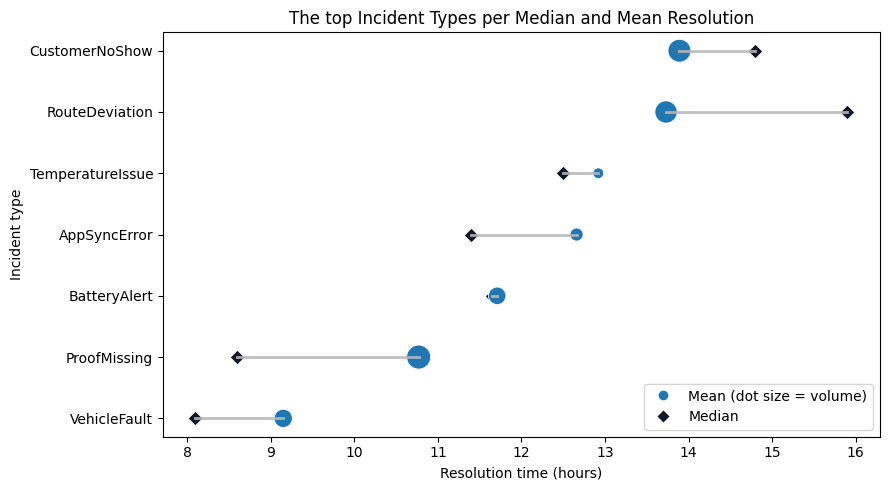

In [130]:


plot_df = incident_resolution_overview.reset_index().copy()

N = 15
plot_df = plot_df.head(N)

plt.figure(figsize=(9, 5))
ax = plt.gca()

#Coneecting the median and the mean for each of the types of incidents
for _, r in plot_df.iterrows():
    ax.plot(
        [r["Median Resolution Hours"], r["Avg. Resolution Hours"]],
        [r["incident_type"], r["incident_type"]],
        color="#B8B8B8",
        linewidth=2,
        alpha=0.9
    )

#Creating the plots for Median
sns.scatterplot(
    data=plot_df,
    x="Median Resolution Hours",
    y="incident_type",
    marker="D",
    s=55,
    color="#111827",
    edgecolor="white",
    linewidth=0.6,
    legend=False
)

#Creating the mean points with the size being volume
sns.scatterplot(
    data=plot_df,
    x="Avg. Resolution Hours",
    y="incident_type",
    size="Total Incidents",
    sizes=(60, 300),
    color="#1F77B4",
    edgecolor="white",
    linewidth=0.6,
    legend=False
)

#Creating the legend
mean_handle = plt.Line2D([0], [0], marker='o', color='w',
                         markerfacecolor="#1F77B4", markeredgecolor="white",
                         markersize=8, label="Mean (dot size = volume)")
median_handle = plt.Line2D([0], [0], marker='D', color='w',
                           markerfacecolor="#111827", markeredgecolor="white",
                           markersize=7, label="Median")

plt.legend(handles=[mean_handle, median_handle], loc="lower right", frameon=True)

plt.title(f"The top Incident Types per Median and Mean Resolution")
plt.xlabel("Resolution time (hours)")
plt.ylabel("Incident type")
plt.tight_layout()
plt.show()

# customer impact

In [45]:
complaints_and_deliveries_df = complaints_df.merge(
    deliveries_df,
    on="order_id",
    how="left",
    indicator=True
)

In [46]:
complaint_delivery_rec_overview = (
    complaints_and_deliveries_df["_merge"]
    .value_counts()
    .to_frame(name="N. Records")
)

complaint_delivery_rec_overview = complaint_delivery_rec_overview.drop(
    index="right_only",
    errors="ignore"
)

complaint_delivery_rec_overview["Total %"] = (
    complaint_delivery_rec_overview["N. Records"] /
    complaint_delivery_rec_overview["N. Records"].sum() * 100
).round(2)

complaint_delivery_rec_overview = complaint_delivery_rec_overview.rename(index={
    "both": "Complaint Linked to Delivery Record",
    "left_only": "Complaint does not have Delivery Record"
})

table_formatting(
    complaint_delivery_rec_overview,
    "Complaint and Deliveries Record Overview"
)

,N. Records,Total %
Complaint Linked To Delivery Record,232,72.50
Complaint Does Not Have Delivery Record,88,27.50


In [47]:
complaints_and_customers_df = complaints_and_deliveries_df.merge(
    customers_df,
    on="customer_id",
    how="left"
)

In [48]:

complaint_counts = (complaints_and_customers_df
    .groupby(["customer_type", "complaint_type"])
    .size()
    .unstack(fill_value=0)
)


table_formatting(
    complaint_counts,
    "Complaint Counts by Customer Type"
)


,Appissue,Billing,Damage,Delay,Driverbehaviour,Missedpickup,Supportexperience
Consumer,35,10,13,76,39,52,17
Enterprise,7,2,0,10,4,4,1
Sme,11,4,2,15,8,8,2


In [132]:

overall_by_type = complaint_counts.sum(axis=0).sort_values(ascending=False).rename("Total complaints")
table_formatting(
    overall_by_type.reset_index().rename(columns={"index": "complaint_type"}),
    "Total N. of Complaints by Complaint Type"
)


,Complaint Type,Total Complaints
0,Delay,101
1,MissedPickup,64
2,AppIssue,53
3,DriverBehaviour,51
4,SupportExperience,20
5,Billing,16
6,Damage,15


In [133]:

count_df = complaint_counts.copy()
count_df.index = [f"{ct} (n={int(totals[ct])})" for ct in count_df.index]

plt.figure(figsize=(11, 5))
sns.heatmap(
    count_df,
    annot=True,
    fmt="d",
    cmap="YlOrBr",
    linewidths=0.3,
    linecolor="white",
    cbar_kws={"label": "Complaint count"}
)
plt.title("N. of complaints per customer type")
plt.xlabel("Complaint type")
plt.ylabel("Customer type")
plt.tight_layout()
plt.show()

NameError: name 'totals' is not defined

In [ ]:
p = delay_by_customer_type["Delay complaints (count)"] / delay_by_customer_type["Total complaints (all types)"]
n = delay_by_customer_type["Total complaints (all types)"]
delay_by_customer_type["delay_ci95_pp"] = (1.96 * np.sqrt(p * (1 - p) / n) * 100).round(2)

In [ ]:
delay_by_customer_type